In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [2]:
df = pd.read_csv("/content/data.csv", sep=";")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
print("Column names:")
for number, column in enumerate(df.columns, start=1):
    print(f"{number}. {column}")

print("\nDataset information:")
df.info()

Column names:
1. Marital status
2. Application mode
3. Application order
4. Course
5. Daytime/evening attendance	
6. Previous qualification
7. Previous qualification (grade)
8. Nacionality
9. Mother's qualification
10. Father's qualification
11. Mother's occupation
12. Father's occupation
13. Admission grade
14. Displaced
15. Educational special needs
16. Debtor
17. Tuition fees up to date
18. Gender
19. Scholarship holder
20. Age at enrollment
21. International
22. Curricular units 1st sem (credited)
23. Curricular units 1st sem (enrolled)
24. Curricular units 1st sem (evaluations)
25. Curricular units 1st sem (approved)
26. Curricular units 1st sem (grade)
27. Curricular units 1st sem (without evaluations)
28. Curricular units 2nd sem (credited)
29. Curricular units 2nd sem (enrolled)
30. Curricular units 2nd sem (evaluations)
31. Curricular units 2nd sem (approved)
32. Curricular units 2nd sem (grade)
33. Curricular units 2nd sem (without evaluations)
34. Unemployment rate
35. Infla

In [4]:
summary = pd.DataFrame({
    "Data type": df.dtypes,
    "Missing values": df.isnull().sum(),
    "Unique values": df.nunique()
})

display(summary)

,Data type,Missing values,Unique values
Marital status,int64,0,6
Application mode,int64,0,18
Application order,int64,0,8
Course,int64,0,17
Daytime/evening attendance\t,int64,0,2
Previous qualification,int64,0,17
Previous qualification (grade),float64,0,101
Nacionality,int64,0,21
Mother's qualification,int64,0,29
Father's qualification,int64,0,34


In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isnull().sum().sum())
print("Target column:", df.columns[-1])
print("\nTarget distribution:")
print(df["Target"].value_counts())

Duplicate rows: 0
Total missing values: 0
Target column: Target

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


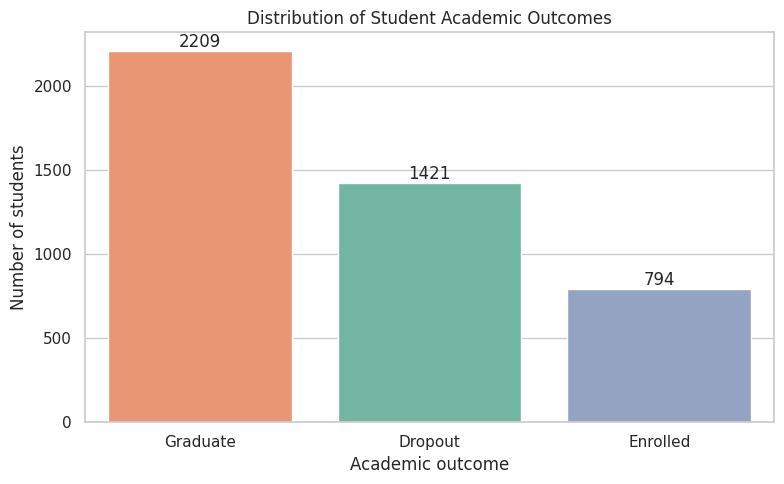

In [6]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Target",
    order=df["Target"].value_counts().index,
    hue="Target",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Student Academic Outcomes")
plt.xlabel("Academic outcome")
plt.ylabel("Number of students")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


In [7]:
target_summary = pd.DataFrame({
    "Count": df["Target"].value_counts(),
    "Percentage": df["Target"].value_counts(normalize=True).mul(100).round(2)
})

display(target_summary)


,Count,Percentage
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


## Feature Selection and Prediction Point

In [8]:
second_semester_columns = [
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)"
]

df_model = df.drop(columns=second_semester_columns).copy()

print("Original dataset shape:", df.shape)
print("Modelling dataset shape:", df_model.shape)
print("\nRemoved columns:")

for column in second_semester_columns:
    print("-", column)

Original dataset shape: (4424, 37)
Modelling dataset shape: (4424, 31)

Removed columns:
- Curricular units 2nd sem (credited)
- Curricular units 2nd sem (enrolled)
- Curricular units 2nd sem (evaluations)
- Curricular units 2nd sem (approved)
- Curricular units 2nd sem (grade)
- Curricular units 2nd sem (without evaluations)


In [9]:
categorical_features = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

numerical_features = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))
print("Total predictors:", len(categorical_features) + len(numerical_features))

Categorical features: 18
Numerical features: 12
Total predictors: 30


In [10]:
# Clean hidden spaces and tab characters from column names
df_model.columns = df_model.columns.str.strip()

print("Column names cleaned successfully.")

Column names cleaned successfully.


In [11]:
selected_features = categorical_features + numerical_features
expected_features = df_model.drop(columns="Target").columns.tolist()

missing_from_lists = sorted(
    set(expected_features) - set(selected_features)
)

extra_in_lists = sorted(
    set(selected_features) - set(expected_features)
)

duplicated_features = pd.Series(selected_features)[
    pd.Series(selected_features).duplicated()
].tolist()

print("Missing from feature lists:", missing_from_lists)
print("Unexpected features:", extra_in_lists)
print("Duplicated features:", duplicated_features)

Missing from feature lists: []
Unexpected features: []
Duplicated features: []


In [12]:
important_numerical_features = [
    "Age at enrollment",
    "Admission grade",
    "Previous qualification (grade)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (evaluations)"
]

df_model[important_numerical_features].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age at enrollment,4424.0,23.27,7.59,17.0,19.0,20.00,25.0,70.00
Admission grade,4424.0,126.98,14.48,95.0,117.9,126.10,134.8,190.00
Previous qualification (grade),4424.0,132.61,13.19,95.0,125.0,133.10,140.0,190.00
Curricular units 1st sem (approved),4424.0,4.71,3.09,0.0,3.0,5.00,6.0,26.00
Curricular units 1st sem (grade),4424.0,10.64,4.84,0.0,11.0,12.29,13.4,18.88
Curricular units 1st sem (evaluations),4424.0,8.30,4.18,0.0,6.0,8.00,10.0,45.00


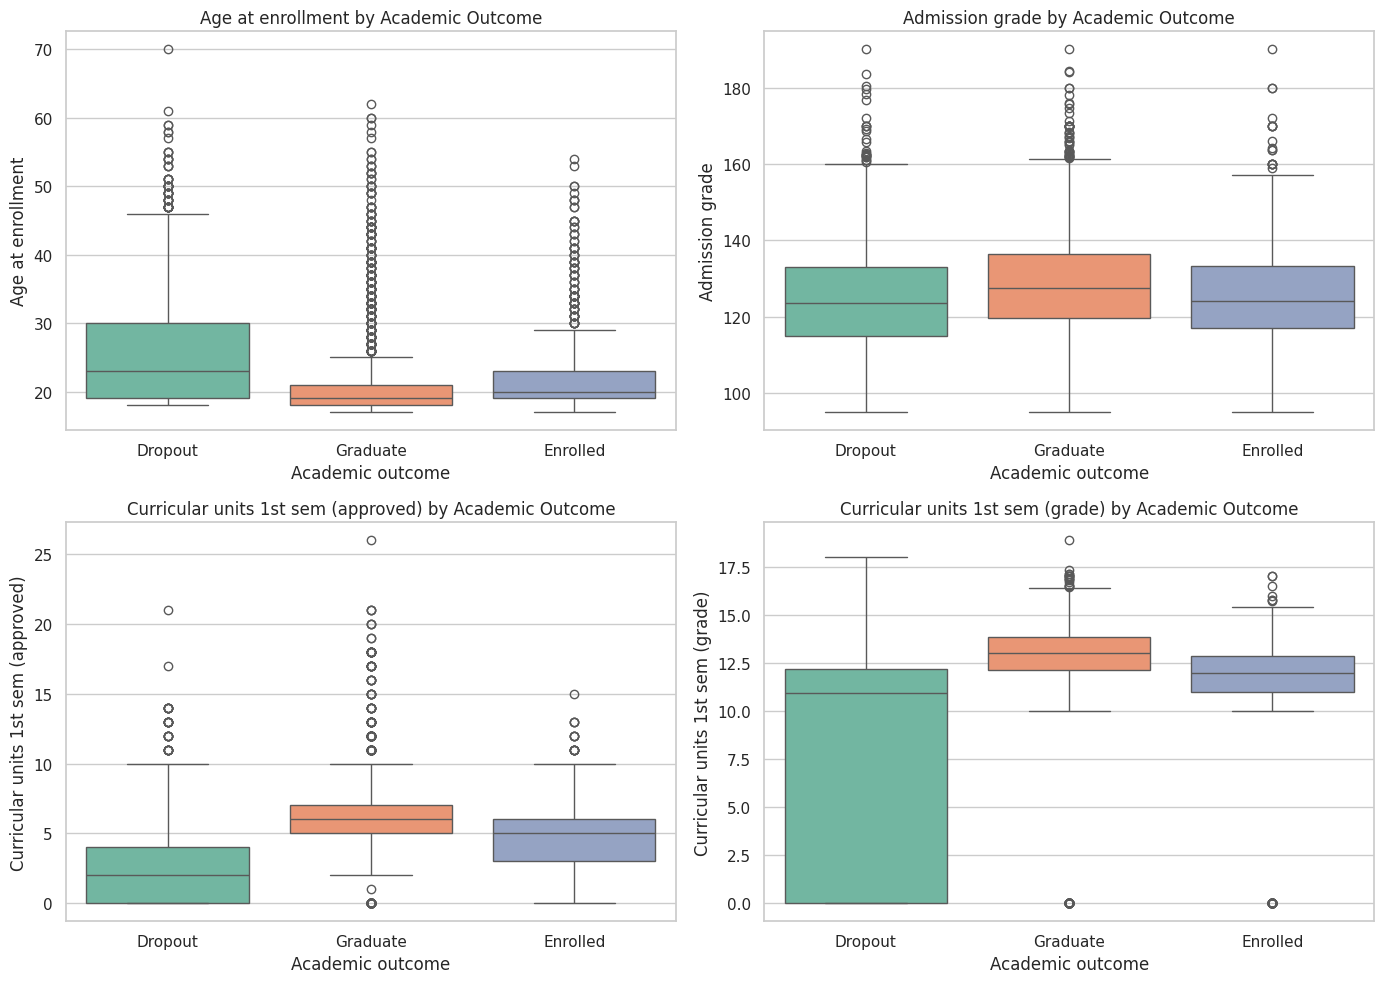

In [13]:
plot_features = [
    "Age at enrollment",
    "Admission grade",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for feature, ax in zip(plot_features, axes.flatten()):
    sns.boxplot(
        data=df_model,
        x="Target",
        y=feature,
        hue="Target",
        palette="Set2",
        legend=False,
        ax=ax
    )

    ax.set_title(f"{feature} by Academic Outcome")
    ax.set_xlabel("Academic outcome")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

In [14]:
df_model["First semester approval rate"] = np.where(
    df_model["Curricular units 1st sem (enrolled)"] > 0,
    df_model["Curricular units 1st sem (approved)"]
    / df_model["Curricular units 1st sem (enrolled)"],
    0
)

numerical_features.append("First semester approval rate")

print(
    df_model.groupby("Target")["First semester approval rate"]
    .agg(["mean", "median", "std"])
    .round(3)
)

           mean  median    std
Target                        
Dropout   0.384   0.333  0.373
Enrolled  0.688   0.800  0.299
Graduate  0.903   1.000  0.200


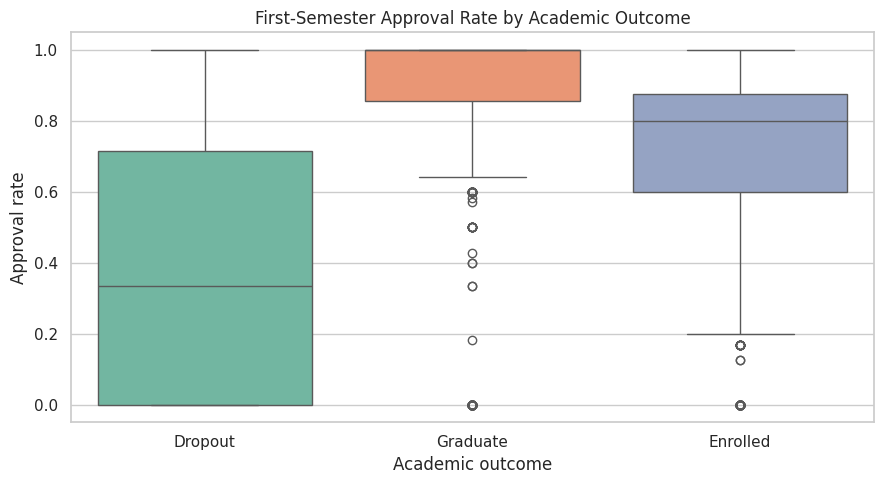

In [15]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_model,
    x="Target",
    y="First semester approval rate",
    hue="Target",
    palette="Set2",
    legend=False
)

plt.title("First-Semester Approval Rate by Academic Outcome")
plt.xlabel("Academic outcome")
plt.ylabel("Approval rate")
plt.tight_layout()
plt.show()

In [16]:
if "First semester approval rate" not in numerical_features:
    numerical_features.append("First semester approval rate")

In [17]:
X = df_model[categorical_features + numerical_features].copy()
y = df_model["Target"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (4424, 31)
Target shape: (4424,)

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (3539, 31)
Testing features: (885, 31)
Training target: (3539,)
Testing target: (885,)


In [19]:
split_distribution = pd.DataFrame({
    "Full dataset": y.value_counts(normalize=True),
    "Training set": y_train.value_counts(normalize=True),
    "Testing set": y_test.value_counts(normalize=True)
}).mul(100).round(2)

display(split_distribution)

,Full dataset,Training set,Testing set
Target,,,
Graduate,49.93,49.93,49.94
Dropout,32.12,32.13,32.09
Enrolled,17.95,17.94,17.97


In [20]:
from sklearn.preprocessing import OneHotEncoder

In [21]:
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

print(preprocessor)

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Previous qualification (grade)',
                                  'Admission grade', 'Age at enrollment',
                                  'Curricular units 1st sem (credited)',
                                  'Curricular units 1st sem (enrolled)',
                                  'Curricular units 1st sem (evaluations)',
                                  'Curricular units 1st sem (approved)',
                                  'Curricu...
                                                                sparse_output=False))]),
                                 ['Marital status', 'Application mode',
                                  'Application order', 'Course',
                  

In [22]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (3539, 31)
Processed training shape: (3539, 246)
Original testing shape: (885, 31)
Processed testing shape: (885, 246)


In [23]:
print("Missing values after preprocessing:",
      np.isnan(X_train_processed).sum())

print("Infinite values after preprocessing:",
      np.isinf(X_train_processed).sum())

Missing values after preprocessing: 0
Infinite values after preprocessing: 0


In [24]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.base import clone

In [25]:
models = {
    "Dummy Baseline": DummyClassifier(
        strategy="most_frequent"
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=10,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

In [26]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

In [27]:
comparison_results = []

for model_name, model in models.items():

    model_pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("classifier", clone(model))
    ])

    scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )

    comparison_results.append({
        "Model": model_name,

        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Accuracy SD": scores["test_accuracy"].std(),

        "CV Macro Precision": scores["test_precision_macro"].mean(),
        "CV Macro Recall": scores["test_recall_macro"].mean(),

        "CV Macro F1 Mean": scores["test_f1_macro"].mean(),
        "CV Macro F1 SD": scores["test_f1_macro"].std(),

        "Training Macro F1": scores["train_f1_macro"].mean()
    })

model_comparison = pd.DataFrame(comparison_results)

model_comparison = model_comparison.sort_values(
    by="CV Macro F1 Mean",
    ascending=False
).reset_index(drop=True)

display(model_comparison.round(4))

,Model,CV Accuracy Mean,CV Accuracy SD,CV Macro Precision,CV Macro Recall,CV Macro F1 Mean,CV Macro F1 SD,Training Macro F1
0,Logistic Regression,0.7197,0.0219,0.6805,0.6833,0.6769,0.0200,0.7333
1,Random Forest,0.7527,0.0165,0.6989,0.6682,0.6761,0.0183,0.9849
2,Gradient Boosting,0.7513,0.0151,0.6897,0.6542,0.6603,0.0184,0.7431
3,Decision Tree,0.6753,0.0164,0.6573,0.6491,0.6401,0.0141,0.7469
4,Dummy Baseline,0.4993,0.0006,0.1664,0.3333,0.2220,0.0002,0.2220


In [28]:
model_comparison["Generalisation Gap"] = (
    model_comparison["Training Macro F1"]
    - model_comparison["CV Macro F1 Mean"]
)

display(
    model_comparison[
        [
            "Model",
            "Training Macro F1",
            "CV Macro F1 Mean",
            "Generalisation Gap",
            "CV Macro F1 SD"
        ]
    ].round(4)
)

,Model,Training Macro F1,CV Macro F1 Mean,Generalisation Gap,CV Macro F1 SD
0,Logistic Regression,0.7333,0.6769,0.0563,0.0200
1,Random Forest,0.9849,0.6761,0.3088,0.0183
2,Gradient Boosting,0.7431,0.6603,0.0829,0.0184
3,Decision Tree,0.7469,0.6401,0.1067,0.0141
4,Dummy Baseline,0.2220,0.2220,0.0000,0.0002


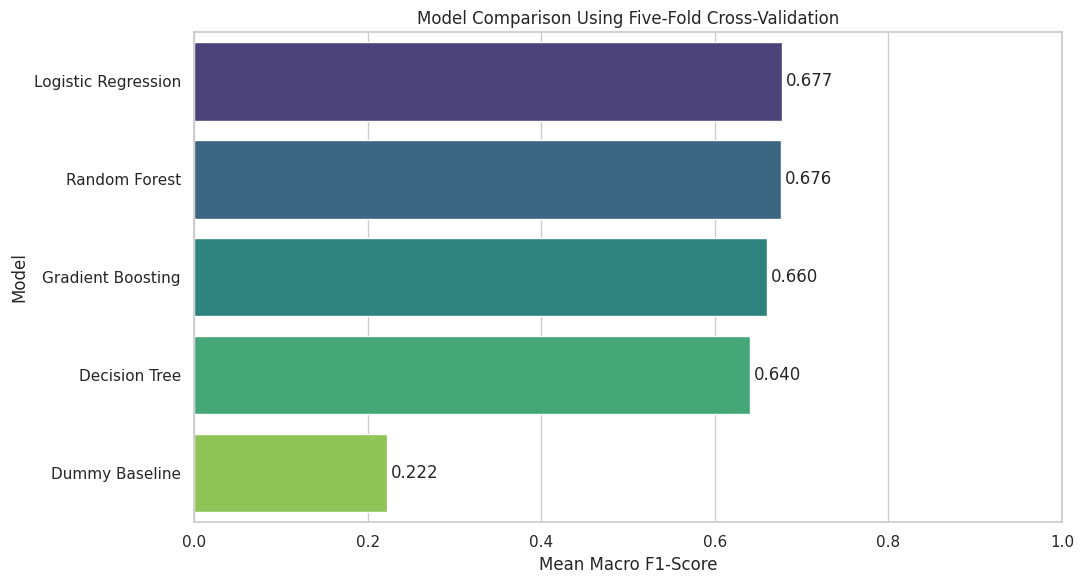

In [29]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=model_comparison,
    x="CV Macro F1 Mean",
    y="Model",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title("Model Comparison Using Five-Fold Cross-Validation")
plt.xlabel("Mean Macro F1-Score")
plt.ylabel("Model")
plt.xlim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

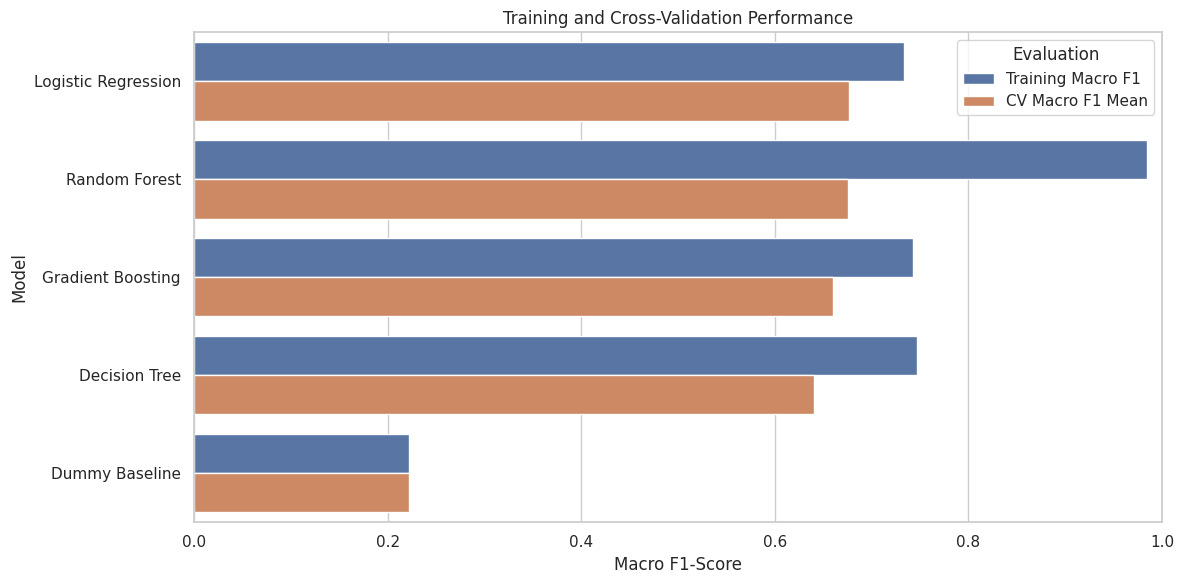

In [30]:
performance_plot = model_comparison[
    ["Model", "Training Macro F1", "CV Macro F1 Mean"]
].melt(
    id_vars="Model",
    var_name="Evaluation",
    value_name="Macro F1"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=performance_plot,
    x="Macro F1",
    y="Model",
    hue="Evaluation",
    palette=["#4C72B0", "#DD8452"]
)

plt.title("Training and Cross-Validation Performance")
plt.xlabel("Macro F1-Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.legend(title="Evaluation")
plt.tight_layout()
plt.show()

In [31]:
from sklearn.model_selection import GridSearchCV


In [32]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("classifier", LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE
    ))
])

In [33]:
logistic_parameters = {
    "classifier__C": [0.01, 0.1, 0.5, 1, 2, 5, 10],
    "classifier__class_weight": [None, "balanced"],
    "classifier__solver": ["lbfgs"]
}

In [34]:
logistic_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_parameters,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    refit=True
)

logistic_search.fit(X_train, y_train)

print("Best parameters:")
print(logistic_search.best_params_)

print("\nBest CV Macro F1:")
print(round(logistic_search.best_score_, 4))

Best parameters:
{'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__solver': 'lbfgs'}

Best CV Macro F1:
0.6793


In [35]:
logistic_tuning_results = pd.DataFrame(
    logistic_search.cv_results_
)

logistic_tuning_summary = logistic_tuning_results[
    [
        "param_classifier__C",
        "param_classifier__class_weight",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].copy()

logistic_tuning_summary["Generalisation Gap"] = (
    logistic_tuning_summary["mean_train_score"]
    - logistic_tuning_summary["mean_test_score"]
)

logistic_tuning_summary = logistic_tuning_summary.sort_values(
    "rank_test_score"
)

display(logistic_tuning_summary.head(10).round(4))

,param_classifier__C,param_classifier__class_weight,mean_train_score,mean_test_score,std_test_score,rank_test_score,Generalisation Gap
3,0.10,balanced,0.7186,0.6793,0.0141,1,0.0393
5,0.50,balanced,0.7301,0.6774,0.0211,2,0.0526
7,1.00,balanced,0.7333,0.6769,0.0200,3,0.0563
9,2.00,balanced,0.7352,0.6745,0.0199,4,0.0608
11,5.00,balanced,0.7368,0.6730,0.0199,5,0.0639
1,0.01,balanced,0.6855,0.6724,0.0137,6,0.0131
13,10.00,balanced,0.7381,0.6698,0.0206,7,0.0682
8,2.00,None,0.7268,0.6599,0.0082,8,0.0669
6,1.00,None,0.7203,0.6589,0.0096,9,0.0614
10,5.00,None,0.7314,0.6585,0.0144,10,0.0729


In [36]:
random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

In [37]:
random_forest_parameters = {
    "classifier__n_estimators": [200, 400],
    "classifier__max_depth": [8, 12, 16],
    "classifier__min_samples_split": [5, 10],
    "classifier__min_samples_leaf": [2, 4],
    "classifier__max_features": ["sqrt"],
    "classifier__class_weight": [None, "balanced"]
}

In [38]:
random_forest_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=random_forest_parameters,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    refit=True
)

random_forest_search.fit(X_train, y_train)

print("Best parameters:")
print(random_forest_search.best_params_)

print("\nBest CV Macro F1:")
print(round(random_forest_search.best_score_, 4))

Best parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 12, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Best CV Macro F1:
0.6974


In [39]:
rf_tuning_results = pd.DataFrame(
    random_forest_search.cv_results_
)

rf_tuning_summary = rf_tuning_results[
    [
        "param_classifier__n_estimators",
        "param_classifier__max_depth",
        "param_classifier__min_samples_split",
        "param_classifier__min_samples_leaf",
        "param_classifier__class_weight",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].copy()

rf_tuning_summary["Generalisation Gap"] = (
    rf_tuning_summary["mean_train_score"]
    - rf_tuning_summary["mean_test_score"]
)

rf_tuning_summary = rf_tuning_summary.sort_values(
    "rank_test_score"
)

display(rf_tuning_summary.head(10).round(4))

,param_classifier__n_estimators,param_classifier__max_depth,param_classifier__min_samples_split,param_classifier__min_samples_leaf,param_classifier__class_weight,mean_train_score,mean_test_score,std_test_score,rank_test_score,Generalisation Gap
32,200,12,5,2,balanced,0.8405,0.6974,0.0243,1,0.1431
46,200,16,10,4,balanced,0.8219,0.6973,0.0186,2,0.1246
40,200,16,5,2,balanced,0.9037,0.6969,0.0275,3,0.2068
42,200,16,10,2,balanced,0.8650,0.6948,0.0274,4,0.1702
43,400,16,10,2,balanced,0.8666,0.6946,0.0226,5,0.1719
44,200,16,5,4,balanced,0.8299,0.6942,0.0214,6,0.1357
45,400,16,5,4,balanced,0.8301,0.6938,0.0203,7,0.1363
35,400,12,10,2,balanced,0.8202,0.6934,0.0240,8,0.1268
38,200,12,10,4,balanced,0.7914,0.6930,0.0243,9,0.0985
47,400,16,10,4,balanced,0.8229,0.6926,0.0201,10,0.1303


In [40]:
tuned_comparison = pd.DataFrame({
    "Model": [
        "Original Logistic Regression",
        "Tuned Logistic Regression",
        "Original Random Forest",
        "Tuned Random Forest"
    ],
    "CV Macro F1": [
        0.6769,
        logistic_search.best_score_,
        0.6761,
        random_forest_search.best_score_
    ]
})

display(
    tuned_comparison.sort_values(
        "CV Macro F1",
        ascending=False
    ).round(4)
)

,Model,CV Macro F1
3,Tuned Random Forest,0.6974
1,Tuned Logistic Regression,0.6793
0,Original Logistic Regression,0.6769
2,Original Random Forest,0.6761


In [41]:
final_model = logistic_search.best_estimator_

y_test_pred = final_model.predict(X_test)
y_test_probability = final_model.predict_proba(X_test)

print("Final model:", final_model.named_steps["classifier"])

Final model: LogisticRegression(C=0.1, class_weight='balanced', max_iter=3000,
                   random_state=42)


In [42]:
final_metrics = {
    "Accuracy": accuracy_score(y_test, y_test_pred),

    "Macro Precision": precision_score(
        y_test,
        y_test_pred,
        average="macro"
    ),

    "Macro Recall": recall_score(
        y_test,
        y_test_pred,
        average="macro"
    ),

    "Macro F1": f1_score(
        y_test,
        y_test_pred,
        average="macro"
    ),

    "Weighted F1": f1_score(
        y_test,
        y_test_pred,
        average="weighted"
    )
}

final_metrics_table = pd.DataFrame(
    final_metrics.items(),
    columns=["Metric", "Test score"]
)

display(final_metrics_table.round(4))

,Metric,Test score
0,Accuracy,0.7073
1,Macro Precision,0.6774
2,Macro Recall,0.6784
3,Macro F1,0.6692
4,Weighted F1,0.7199


In [43]:
class_report = classification_report(
    y_test,
    y_test_pred,
    output_dict=True
)

class_report_df = pd.DataFrame(class_report).T

display(class_report_df.round(4))

,precision,recall,f1-score,support
Dropout,0.8059,0.6725,0.7332,284.0000
Enrolled,0.3966,0.5912,0.4747,159.0000
Graduate,0.8297,0.7715,0.7995,442.0000
accuracy,0.7073,0.7073,0.7073,0.7073
macro avg,0.6774,0.6784,0.6692,885.0000
weighted avg,0.7442,0.7073,0.7199,885.0000


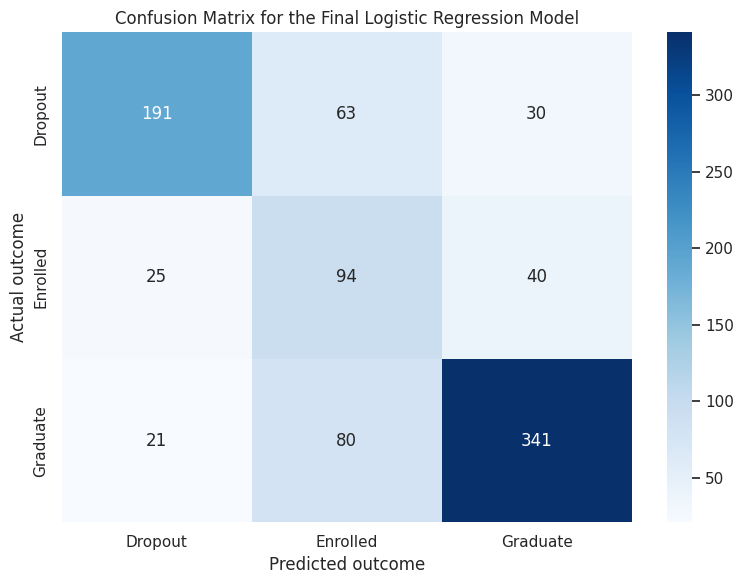

In [44]:
class_order = [
    "Dropout",
    "Enrolled",
    "Graduate"
]

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=class_order
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_order,
    yticklabels=class_order
)

plt.title("Confusion Matrix for the Final Logistic Regression Model")
plt.xlabel("Predicted outcome")
plt.ylabel("Actual outcome")
plt.tight_layout()
plt.show()

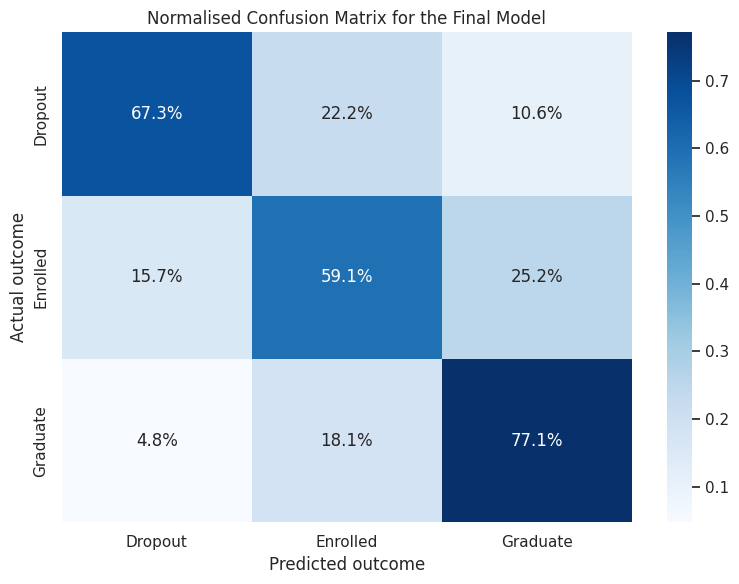

In [45]:
cm_normalised = confusion_matrix(
    y_test,
    y_test_pred,
    labels=class_order,
    normalize="true"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_normalised,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    xticklabels=class_order,
    yticklabels=class_order
)

plt.title("Normalised Confusion Matrix for the Final Model")
plt.xlabel("Predicted outcome")
plt.ylabel("Actual outcome")
plt.tight_layout()
plt.show()

In [46]:
final_performance_comparison = pd.DataFrame({
    "Evaluation": [
        "Cross-validation",
        "Unseen test set"
    ],
    "Macro F1": [
        logistic_search.best_score_,
        final_metrics["Macro F1"]
    ]
})

display(final_performance_comparison.round(4))

,Evaluation,Macro F1
0,Cross-validation,0.6793
1,Unseen test set,0.6692


In [47]:
model_classes = final_model.named_steps[
    "classifier"
].classes_

probability_df = pd.DataFrame(
    y_test_probability,
    columns=[
        f"Probability: {label}"
        for label in model_classes
    ]
)

prediction_examples = X_test.reset_index(drop=True).copy()

prediction_examples["Actual outcome"] = (
    y_test.reset_index(drop=True)
)

prediction_examples["Predicted outcome"] = y_test_pred

prediction_examples = pd.concat(
    [prediction_examples, probability_df],
    axis=1
)

display(
    prediction_examples[
        [
            "Actual outcome",
            "Predicted outcome"
        ] + [
            f"Probability: {label}"
            for label in model_classes
        ]
    ].head(10).round(4)
)

,Actual outcome,Predicted outcome,Probability: Dropout,Probability: Enrolled,Probability: Graduate
0,Graduate,Graduate,0.0611,0.3345,0.6043
1,Graduate,Graduate,0.0809,0.3046,0.6145
2,Enrolled,Enrolled,0.1690,0.5593,0.2717
3,Graduate,Graduate,0.0465,0.2059,0.7475
4,Graduate,Graduate,0.0955,0.2208,0.6838
5,Graduate,Dropout,0.3960,0.2718,0.3323
6,Graduate,Graduate,0.0841,0.2189,0.6970
7,Graduate,Graduate,0.0635,0.1758,0.7607
8,Graduate,Graduate,0.1049,0.4141,0.4810
9,Graduate,Graduate,0.1251,0.2486,0.6263


In [48]:
import joblib

In [49]:
joblib.dump(
    final_model,
    "student_outcome_model.joblib"
)

print("Final model saved successfully.")

Final model saved successfully.


In [50]:
loaded_model = joblib.load(
    "student_outcome_model.joblib"
)

loaded_predictions = loaded_model.predict(X_test)

print(
    "Loaded model produces identical predictions:",
    np.array_equal(y_test_pred, loaded_predictions)
)

Loaded model produces identical predictions: True


In [51]:
from sklearn.inspection import permutation_importance


In [52]:
permutation_result = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": permutation_result.importances_mean,
    "Importance SD": permutation_result.importances_std
})

feature_importance = feature_importance.sort_values(
    "Importance Mean",
    ascending=False
).reset_index(drop=True)

display(feature_importance.head(15).round(4))

,Feature,Importance Mean,Importance SD
0,Curricular units 1st sem (approved),0.1703,0.0112
1,Tuition fees up to date,0.0455,0.0049
2,First semester approval rate,0.0448,0.0080
3,Curricular units 1st sem (evaluations),0.0326,0.0082
4,Curricular units 1st sem (enrolled),0.0291,0.0053
5,Course,0.0205,0.0057
6,Curricular units 1st sem (grade),0.0163,0.0023
7,Debtor,0.0111,0.0057
8,Father's occupation,0.0107,0.0061
9,Scholarship holder,0.0087,0.0050


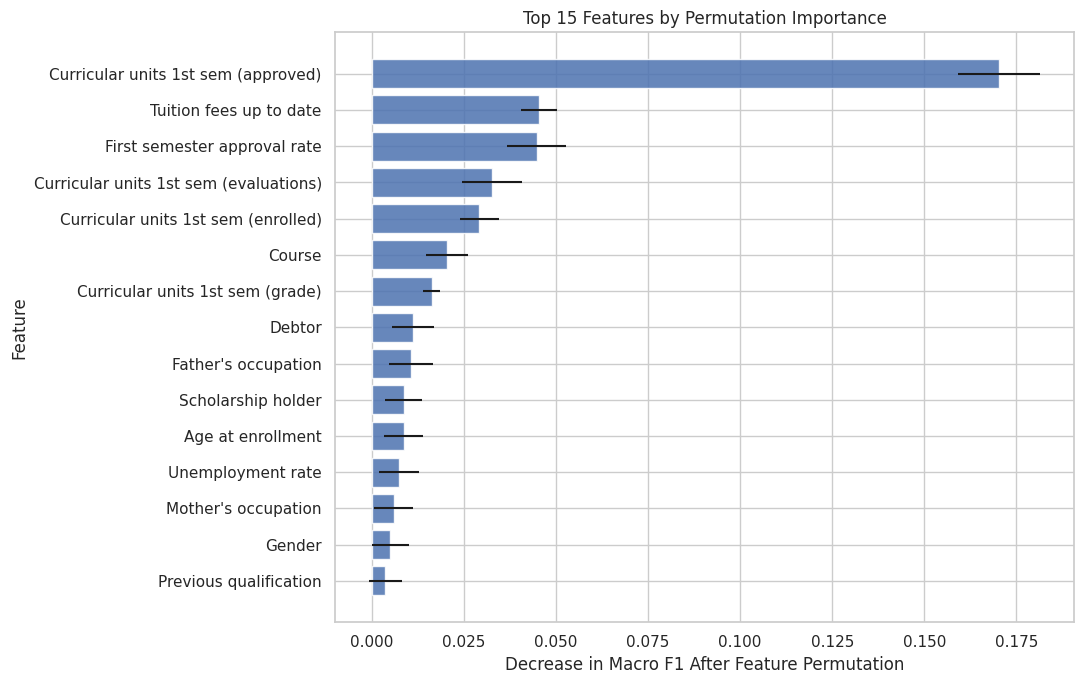

In [53]:
top_features = feature_importance.head(15).sort_values(
    "Importance Mean",
    ascending=True
)

plt.figure(figsize=(11, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance Mean"],
    xerr=top_features["Importance SD"],
    color="#4C72B0",
    alpha=0.85
)

plt.title("Top 15 Features by Permutation Importance")
plt.xlabel("Decrease in Macro F1 After Feature Permutation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [54]:
app_information = {
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "model_classes": model_classes.tolist(),
    "final_metrics": final_metrics,
    "selected_model": "Logistic Regression",
    "prediction_point": "End of first semester"
}

joblib.dump(
    app_information,
    "app_information.joblib"
)

print("Streamlit supporting information saved.")

Streamlit supporting information saved.


In [55]:
loaded_app_information = joblib.load(
    "app_information.joblib"
)

print(loaded_app_information)

{'categorical_features': ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International'], 'numerical_features': ['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'First semester approval rate'], 'model_classes': ['Dropout', 'Enrolled', 'Graduate'], 'final_metrics': {'Accuracy': 0.7073446327683616, 'Macro Precision': 0.6774051146221524, 'Macro Recall': 0.678407797496916, 'Macro F

In [56]:
categorical_options = {
    feature: sorted(
        df_model[feature].dropna().unique().tolist()
    )
    for feature in categorical_features
}

numerical_settings = {
    feature: {
        "minimum": float(df_model[feature].min()),
        "maximum": float(df_model[feature].max()),
        "median": float(df_model[feature].median())
    }
    for feature in numerical_features
    if feature != "First semester approval rate"
}

app_information = {
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "categorical_options": categorical_options,
    "numerical_settings": numerical_settings,
    "model_classes": model_classes.tolist(),
    "final_metrics": final_metrics,
    "selected_model": "Tuned Logistic Regression",
    "selected_parameters": {
        "C": 0.1,
        "class_weight": "balanced",
        "solver": "lbfgs"
    },
    "prediction_point": "End of first semester"
}

joblib.dump(
    app_information,
    "app_information.joblib"
)

print("Updated Streamlit metadata saved.")

Updated Streamlit metadata saved.


In [57]:
loaded_app_information = joblib.load(
    "app_information.joblib"
)

print("Categorical variables:",
      len(loaded_app_information["categorical_options"]))

print("Numerical input variables:",
      len(loaded_app_information["numerical_settings"]))

print("Model classes:",
      loaded_app_information["model_classes"])

Categorical variables: 18
Numerical input variables: 12
Model classes: ['Dropout', 'Enrolled', 'Graduate']


In [58]:
from google.colab import files

files.download("student_outcome_model.joblib")
files.download("app_information.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
from google.colab import files

files.download("student_outcome_model.joblib")
files.download("app_information.joblib")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
import sklearn
print(sklearn.__version__)

1.6.1
